# Task 5: Interactive Business Dashboard in Streamlit
**DevelopersHub Corporation – Advanced Data Science Internship**

## Objective
Develop an interactive dashboard for analyzing sales, profit, and segment-wise performance using the Global Superstore Dataset.

## Dataset
Global Superstore Dataset (Kaggle)

## Skills Covered
- Business Intelligence (BI) Dashboarding
- Data Storytelling
- User Interactivity with Streamlit
- Visual KPI Analysis

## 0. Install & Import Libraries

In [21]:
# ── Install required libraries ───────────────────────────────────────────────
!pip install streamlit --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
print('Libraries loaded!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 59.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 66.6 MB/s eta 0:00:00
Libraries loaded!


In [22]:
# ── Install Localtunnel ──────────────────────────────────────────────────────
!sudo apt-get update > /dev/null
!sudo apt-get install -y nodejs npm > /dev/null
!sudo npm install -g localtunnel > /dev/null
print('Localtunnel installed!')

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 190.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Localtunnel installed!


## 1. Loading Dataset
 `Global_Superstore2.csv`


In [2]:
# ── Upload Dataset ────────────────────────────────────────────────────────────
from google.colab import files
uploaded = files.upload()

import io
import pandas as pd # Added this line to ensure pandas is imported
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]), encoding='latin-1')
print(f'Dataset shape: {df.shape}')
df.head()

Saving Global_Superstore2.csv to Global_Superstore2 (1).csv
Dataset shape: (51290, 24)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,32298,CA-2012-124891,31-07-2012,31-07-2012,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical
1,26341,IN-2013-77878,05-02-2013,07-02-2013,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical
2,25330,IN-2013-71249,17-10-2013,18-10-2013,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium
3,13524,ES-2013-1579342,28-01-2013,30-01-2013,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium
4,47221,SG-2013-4320,05-11-2013,06-11-2013,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical


## 2. Dataset Overview & EDA

In [5]:
print('Shape:', df.shape)
print('\nColumn Names:', df.columns.tolist())
print('\nData Types:')
print(df.dtypes)
print('\nMissing Values:')
print(df.isnull().sum()[df.isnull().sum() > 0])
print('\nStatistical Summary:')
df.describe()

Shape: (51290, 24)

Column Names: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'City', 'State', 'Country', 'Postal Code', 'Market', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Shipping Cost', 'Order Priority']

Data Types:
Row ID              int64
Order ID           object
Order Date         object
Ship Date          object
Ship Mode          object
Customer ID        object
Customer Name      object
Segment            object
City               object
State              object
Country            object
Postal Code       float64
Market             object
Region             object
Product ID         object
Category           object
Sub-Category       object
Product Name       object
Sales             float64
Quantity            int64
Discount          float64
Profit            float64
Shipping Cost     float64
Order Priority     object
dtype: object

Missing V

,Row ID,Postal Code,Sales,Quantity,Discount,Profit,Shipping Cost
count,51290.00000,9994.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,25645.50000,55190.379428,246.490581,3.476545,0.142908,28.610982,26.375915
std,14806.29199,32063.693350,487.565361,2.278766,0.212280,174.340972,57.296804
min,1.00000,1040.000000,0.444000,1.000000,0.000000,-6599.978000,0.000000
25%,12823.25000,23223.000000,30.758625,2.000000,0.000000,0.000000,2.610000
50%,25645.50000,56430.500000,85.053000,3.000000,0.000000,9.240000,7.790000
75%,38467.75000,90008.000000,251.053200,5.000000,0.200000,36.810000,24.450000
max,51290.00000,99301.000000,22638.480000,14.000000,0.850000,8399.976000,933.570000


In [6]:
# ── Parse Dates & Basic Cleaning ─────────────────────────────────────────────
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date']  = pd.to_datetime(df['Ship Date'])
df['Year']       = df['Order Date'].dt.year
df['Month']      = df['Order Date'].dt.month
df['Month_Name'] = df['Order Date'].dt.strftime('%b')

print('Unique Regions:', df['Region'].unique())
print('Unique Categories:', df['Category'].unique())
print('Unique Segments:', df['Segment'].unique())
print('Year range:', df['Year'].min(), '-', df['Year'].max())

/tmp/ipykernel_603/2511896431.py:2: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Order Date'] = pd.to_datetime(df['Order Date'])
/tmp/ipykernel_603/2511896431.py:3: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Ship Date']  = pd.to_datetime(df['Ship Date'])


Unique Regions: ['East' 'Oceania' 'Central' 'Africa' 'West' 'South' 'Central Asia' 'EMEA'
 'North Asia' 'North' 'Caribbean' 'Southeast Asia' 'Canada']
Unique Categories: ['Technology' 'Furniture' 'Office Supplies']
Unique Segments: ['Consumer' 'Corporate' 'Home Office']
Year range: 2011 - 2014


## 3. Exploratory Data Analysis

In [7]:
# ── KPI Overview ─────────────────────────────────────────────────────────────
total_sales   = df['Sales'].sum()
total_profit  = df['Profit'].sum()
total_orders  = df['Order ID'].nunique()
profit_margin = (total_profit / total_sales) * 100

print('=' * 40)
print(f'  Total Sales    : ${total_sales:,.0f}')
print(f'  Total Profit   : ${total_profit:,.0f}')
print(f'  Total Orders   : {total_orders:,}')
print(f'  Profit Margin  : {profit_margin:.1f}%')
print('=' * 40)

  Total Sales    : $12,642,502
  Total Profit   : $1,467,457
  Total Orders   : 25,035
  Profit Margin  : 11.6%


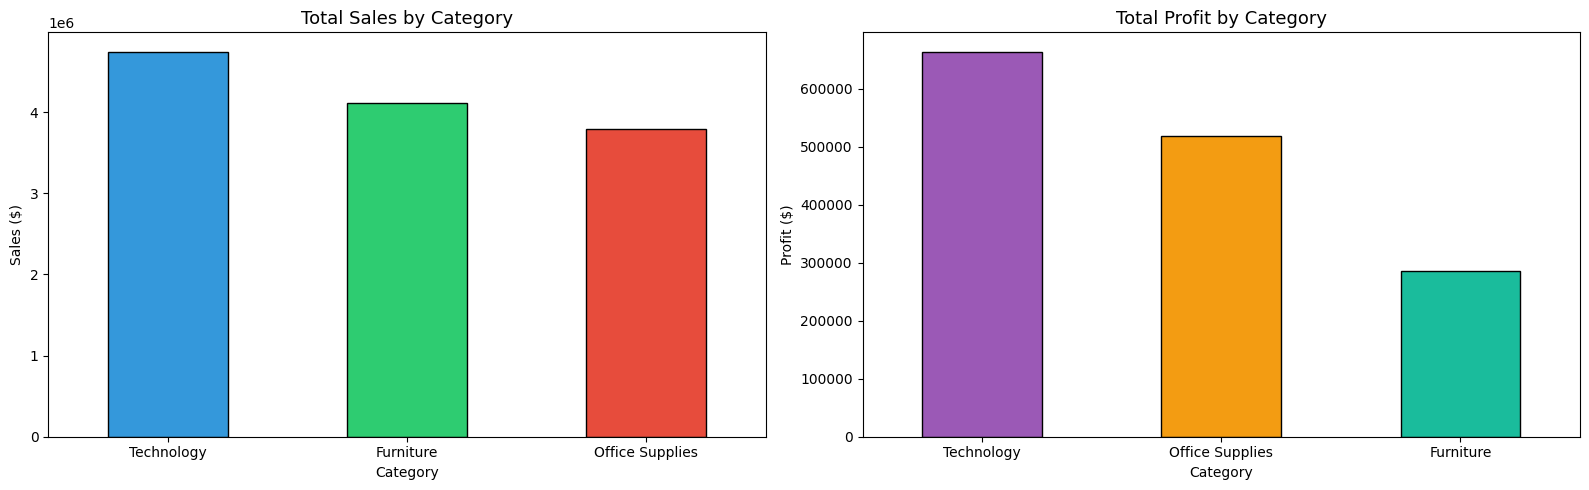

In [9]:
# ── Sales & Profit by Category ───────────────────────────────────────────────
import matplotlib.pyplot as plt # Added this line
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

cat_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
cat_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)

cat_sales.plot(kind='bar', ax=axes[0], color=['#3498db','#2ecc71','#e74c3c'], edgecolor='black')
axes[0].set_title('Total Sales by Category', fontsize=13)
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Sales ($)')
axes[0].tick_params(axis='x', rotation=0)

cat_profit.plot(kind='bar', ax=axes[1], color=['#9b59b6','#f39c12','#1abc9c'], edgecolor='black')
axes[1].set_title('Total Profit by Category', fontsize=13)
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Profit ($)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

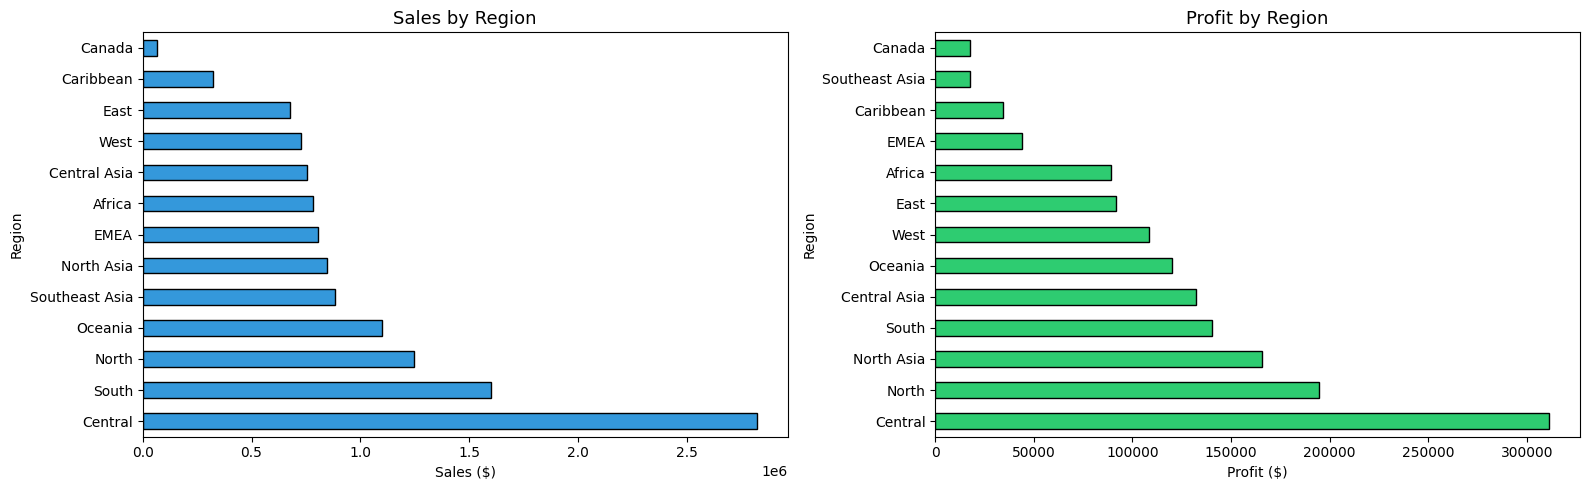

In [10]:
# ── Sales by Region ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
region_profit = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)

region_sales.plot(kind='barh', ax=axes[0], color='#3498db', edgecolor='black')
axes[0].set_title('Sales by Region', fontsize=13)
axes[0].set_xlabel('Sales ($)')

colors = ['#2ecc71' if x >= 0 else '#e74c3c' for x in region_profit]
region_profit.plot(kind='barh', ax=axes[1], color=colors, edgecolor='black')
axes[1].set_title('Profit by Region', fontsize=13)
axes[1].set_xlabel('Profit ($)')

plt.tight_layout()
plt.show()

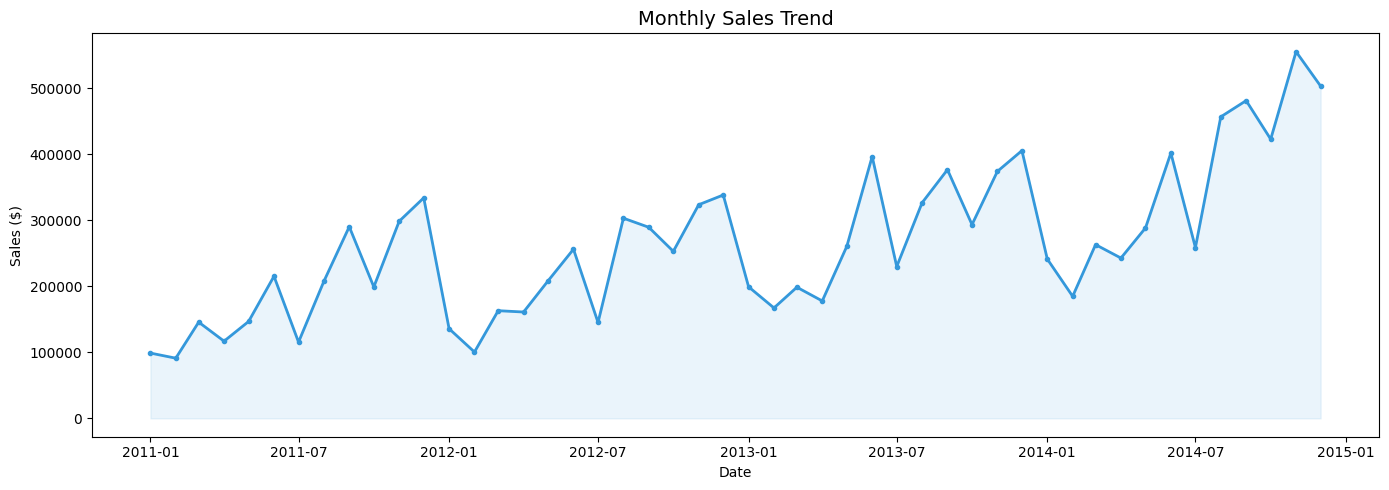

In [11]:
# ── Sales Trend Over Time ─────────────────────────────────────────────────────
monthly_sales = df.groupby(['Year','Month'])['Sales'].sum().reset_index()
monthly_sales['Date'] = pd.to_datetime(monthly_sales[['Year','Month']].assign(DAY=1))

plt.figure(figsize=(14, 5))
plt.plot(monthly_sales['Date'], monthly_sales['Sales'], color='#3498db', linewidth=2, marker='o', markersize=3)
plt.fill_between(monthly_sales['Date'], monthly_sales['Sales'], alpha=0.1, color='#3498db')
plt.title('Monthly Sales Trend', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Sales ($)')
plt.tight_layout()
plt.show()

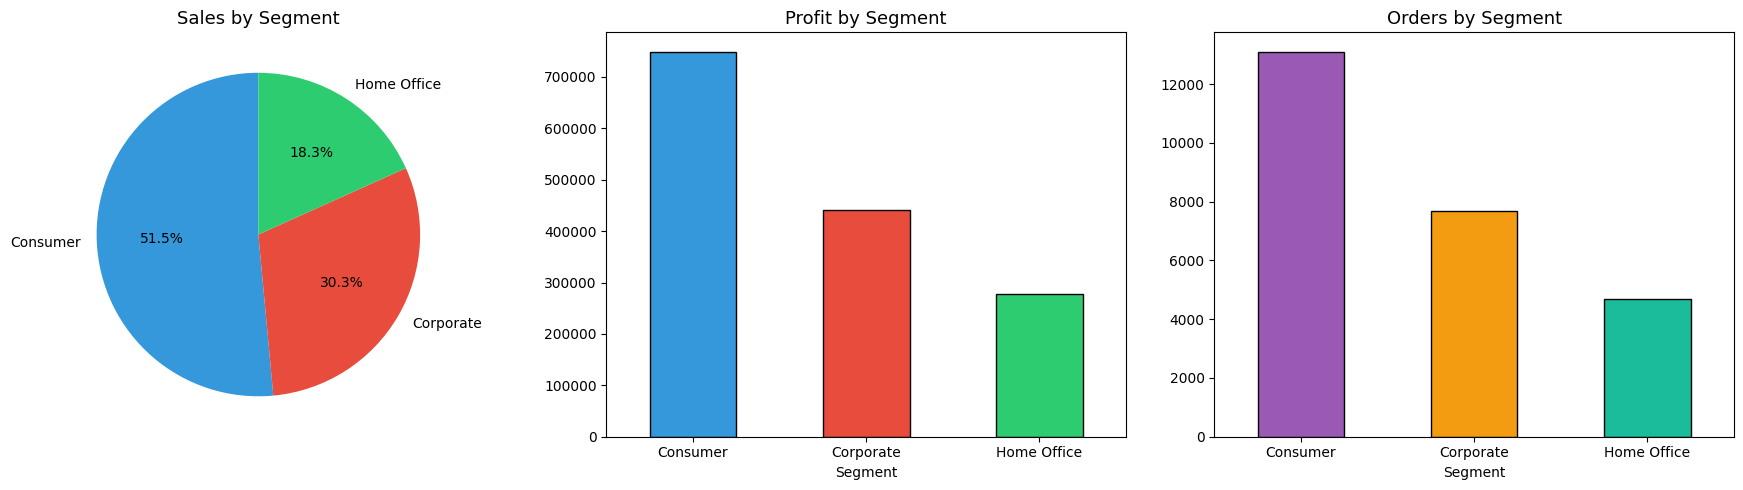

In [12]:
# ── Segment-wise Analysis ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

seg_sales = df.groupby('Segment')['Sales'].sum()
seg_profit = df.groupby('Segment')['Profit'].sum()
seg_orders = df.groupby('Segment')['Order ID'].nunique()

seg_sales.plot(kind='pie', autopct='%1.1f%%', ax=axes[0],
               colors=['#3498db','#e74c3c','#2ecc71'], startangle=90)
axes[0].set_title('Sales by Segment', fontsize=13)
axes[0].set_ylabel('')

seg_profit.plot(kind='bar', ax=axes[1], color=['#3498db','#e74c3c','#2ecc71'], edgecolor='black')
axes[1].set_title('Profit by Segment', fontsize=13)
axes[1].set_xlabel('Segment')
axes[1].tick_params(axis='x', rotation=0)

seg_orders.plot(kind='bar', ax=axes[2], color=['#9b59b6','#f39c12','#1abc9c'], edgecolor='black')
axes[2].set_title('Orders by Segment', fontsize=13)
axes[2].set_xlabel('Segment')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

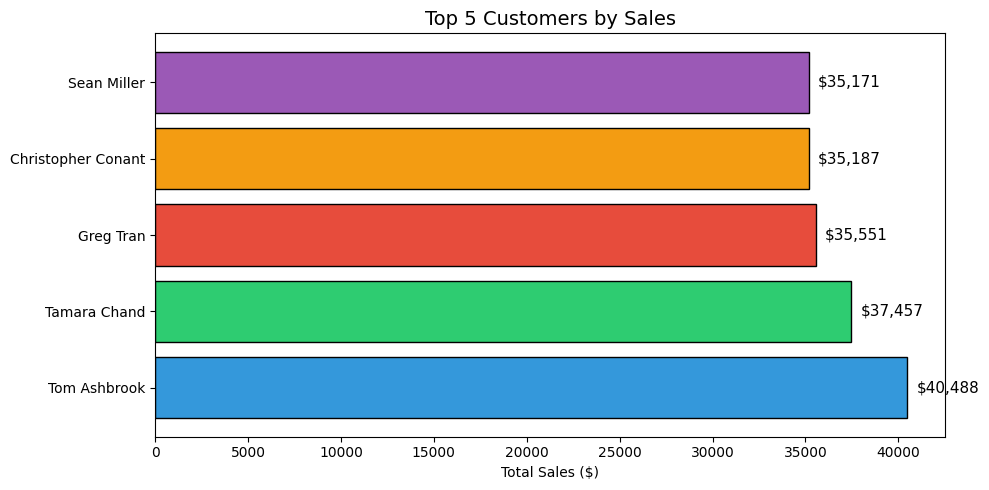


Top 5 Customers:
Customer Name
Tom Ashbrook          40488.07080
Tamara Chand          37457.33300
Greg Tran             35550.95428
Christopher Conant    35187.07640
Sean Miller           35170.93296


In [13]:
# ── Top 5 Customers by Sales ─────────────────────────────────────────────────
top5_customers = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(5)

plt.figure(figsize=(10, 5))
bars = plt.barh(top5_customers.index, top5_customers.values,
                color=['#3498db','#2ecc71','#e74c3c','#f39c12','#9b59b6'], edgecolor='black')
for bar, val in zip(bars, top5_customers.values):
    plt.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
             f'${val:,.0f}', va='center', fontsize=11)
plt.title('Top 5 Customers by Sales', fontsize=14)
plt.xlabel('Total Sales ($)')
plt.tight_layout()
plt.show()
print('\nTop 5 Customers:')
print(top5_customers.to_string())

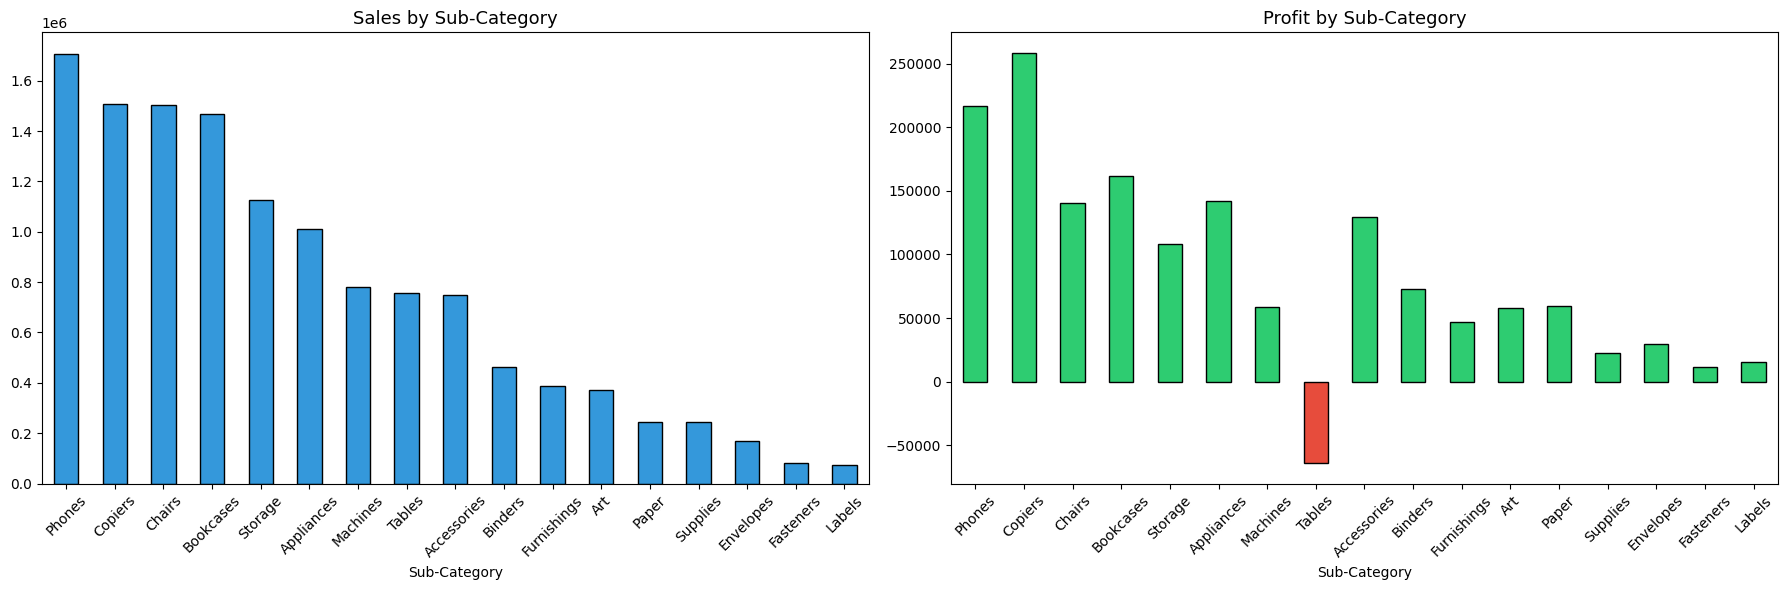

In [14]:
# ── Sub-Category Performance ─────────────────────────────────────────────────
subcat = df.groupby('Sub-Category')[['Sales','Profit']].sum().sort_values('Sales', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

subcat['Sales'].plot(kind='bar', ax=axes[0], color='#3498db', edgecolor='black')
axes[0].set_title('Sales by Sub-Category', fontsize=13)
axes[0].set_xlabel('Sub-Category')
axes[0].tick_params(axis='x', rotation=45)

colors = ['#2ecc71' if x >= 0 else '#e74c3c' for x in subcat['Profit']]
subcat['Profit'].plot(kind='bar', ax=axes[1], color=colors, edgecolor='black')
axes[1].set_title('Profit by Sub-Category', fontsize=13)
axes[1].set_xlabel('Sub-Category')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 4. Streamlit Dashboard
The interactive dashboard is written to a `.py` file and launched via `pyngrok` inside Colab.
Run **all cells in order** — the public URL will appear at the end of the last cell.

In [15]:
# ── Write Streamlit App to File ──────────────────────────────────────────────
app_code = '''
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

st.set_page_config(page_title="Global Superstore Dashboard", layout="wide")

@st.cache_data
def load_data():
    df = pd.read_csv("Global_Superstore2.csv", encoding="latin-1")
    df["Order Date"] = pd.to_datetime(df["Order Date"])
    df["Ship Date"]  = pd.to_datetime(df["Ship Date"])
    df["Year"]       = df["Order Date"].dt.year
    df["Month"]      = df["Order Date"].dt.month
    return df

df = load_data()

# ── Sidebar Filters ──────────────────────────────────────────────────────────
st.sidebar.title("Filters")
regions    = st.sidebar.multiselect("Region",      sorted(df["Region"].unique()),   default=sorted(df["Region"].unique()))
categories = st.sidebar.multiselect("Category",    sorted(df["Category"].unique()), default=sorted(df["Category"].unique()))
subcats    = st.sidebar.multiselect("Sub-Category",sorted(df["Sub-Category"].unique()), default=sorted(df["Sub-Category"].unique()))
years      = st.sidebar.multiselect("Year",        sorted(df["Year"].unique()),     default=sorted(df["Year"].unique()))

filtered = df[
    df["Region"].isin(regions) &
    df["Category"].isin(categories) &
    df["Sub-Category"].isin(subcats) &
    df["Year"].isin(years)
]

# ── Title ────────────────────────────────────────────────────────────────────
st.title("Global Superstore Business Dashboard")
st.markdown("**DevelopersHub Corporation – Advanced Data Science Internship | Task 5**")
st.markdown("---")

# ── KPIs ─────────────────────────────────────────────────────────────────────
total_sales   = filtered["Sales"].sum()
total_profit  = filtered["Profit"].sum()
total_orders  = filtered["Order ID"].nunique()
profit_margin = (total_profit / total_sales * 100) if total_sales > 0 else 0

k1, k2, k3, k4 = st.columns(4)
k1.metric("Total Sales",    f"${total_sales:,.0f}")
k2.metric("Total Profit",   f"${total_profit:,.0f}")
k3.metric("Total Orders",   f"{total_orders:,}")
k4.metric("Profit Margin",  f"{profit_margin:.1f}%")

st.markdown("---")

# ── Row 1: Sales by Category | Sales by Region ───────────────────────────────
c1, c2 = st.columns(2)

with c1:
    st.subheader("Sales by Category")
    cat_s = filtered.groupby("Category")["Sales"].sum().sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(6,4))
    cat_s.plot(kind="bar", ax=ax, color=["#3498db","#2ecc71","#e74c3c"], edgecolor="black")
    ax.set_xlabel("Category"); ax.set_ylabel("Sales ($)")
    ax.tick_params(axis="x", rotation=0)
    st.pyplot(fig); plt.close()

with c2:
    st.subheader("Profit by Region")
    reg_p = filtered.groupby("Region")["Profit"].sum().sort_values()
    fig, ax = plt.subplots(figsize=(6,4))
    colors = ["#e74c3c" if x < 0 else "#2ecc71" for x in reg_p]
    reg_p.plot(kind="barh", ax=ax, color=colors, edgecolor="black")
    ax.set_xlabel("Profit ($)")
    st.pyplot(fig); plt.close()

# ── Row 2: Monthly Trend | Segment Pie ───────────────────────────────────────
c3, c4 = st.columns(2)

with c3:
    st.subheader("Monthly Sales Trend")
    monthly = filtered.groupby(["Year","Month"])["Sales"].sum().reset_index()
    monthly["Date"] = pd.to_datetime(monthly[["Year","Month"]].assign(DAY=1))
    monthly = monthly.sort_values("Date")
    fig, ax = plt.subplots(figsize=(6,4))
    ax.plot(monthly["Date"], monthly["Sales"], color="#3498db", linewidth=2, marker="o", markersize=3)
    ax.fill_between(monthly["Date"], monthly["Sales"], alpha=0.1, color="#3498db")
    ax.set_xlabel("Date"); ax.set_ylabel("Sales ($)")
    plt.xticks(rotation=30)
    st.pyplot(fig); plt.close()

with c4:
    st.subheader("Sales by Segment")
    seg_s = filtered.groupby("Segment")["Sales"].sum()
    fig, ax = plt.subplots(figsize=(6,4))
    ax.pie(seg_s, labels=seg_s.index, autopct="%1.1f%%",
           colors=["#3498db","#e74c3c","#2ecc71"], startangle=90)
    st.pyplot(fig); plt.close()

# ── Row 3: Top 5 Customers | Sub-Category Profit ─────────────────────────────
c5, c6 = st.columns(2)

with c5:
    st.subheader("Top 5 Customers by Sales")
    top5 = filtered.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False).head(5)
    fig, ax = plt.subplots(figsize=(6,4))
    colors_t = ["#3498db","#2ecc71","#e74c3c","#f39c12","#9b59b6"]
    bars = ax.barh(top5.index, top5.values, color=colors_t, edgecolor="black")
    for bar, val in zip(bars, top5.values):
        ax.text(bar.get_width()+200, bar.get_y()+bar.get_height()/2,
                f"${val:,.0f}", va="center", fontsize=9)
    ax.set_xlabel("Sales ($)")
    st.pyplot(fig); plt.close()

with c6:
    st.subheader("Sub-Category Profit")
    sub_p = filtered.groupby("Sub-Category")["Profit"].sum().sort_values()
    fig, ax = plt.subplots(figsize=(6,4))
    colors_s = ["#e74c3c" if x < 0 else "#2ecc71" for x in sub_p]
    sub_p.plot(kind="barh", ax=ax, color=colors_s, edgecolor="black")
    ax.set_xlabel("Profit ($)")
    ax.tick_params(axis="y", labelsize=8)
    st.pyplot(fig); plt.close()

st.markdown("---")
st.caption("DevelopersHub Corporation – Advanced Data Science Internship | Task 5: Streamlit Dashboard")
'''

with open('app.py', 'w') as f:
    f.write(app_code)

print('app.py written successfully!')

app.py written successfully!


In [16]:
# ── Save dataset for Streamlit to read ───────────────────────────────────────
df.to_csv('Global_Superstore2.csv', index=False)
print('Global_Superstore2.csv saved!')

Global_Superstore2.csv saved!


In [ ]:
# ── Launch Streamlit via localtunnel ─────────────────────────────────────────
import subprocess, time

# Kill any existing Streamlit processes
!killall streamlit > /dev/null 2>&1

# Start Streamlit in background
proc = subprocess.Popen(
    ['python', '-m', 'streamlit', 'run', 'app.py', '--server.port', '8501', '--server.headless', 'true'],
    stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL
)
time.sleep(5)

# Open localtunnel
!lt --port 8501

your url is: https://great-places-rhyme.loca.lt


## 5. Conclusion

### Dashboard Features:
The Streamlit dashboard includes the following interactive components:

| Section | Visualization |
|---|---|
| KPI Cards | Total Sales, Profit, Orders, Margin |
| Category Analysis | Bar chart – Sales & Profit by Category |
| Regional Performance | Horizontal bar – Profit by Region |
| Time Series | Monthly Sales Trend with area fill |
| Segment Analysis | Pie chart – Sales by Segment |
| Top Customers | Horizontal bar – Top 5 by Sales |
| Sub-Category | Profit by Sub-Category (red = loss) |

### Sidebar Filters:
Users can filter by **Region**, **Category**, **Sub-Category**, and **Year** — all charts update dynamically.

### Business Insights:
- Technology drives the highest sales but Furniture shows inconsistent profitability
- Consumer segment contributes the most orders overall
- Certain Sub-Categories (Tables, Bookcases) show negative profit — requiring pricing strategy revision
- Sales show consistent growth trend year-over-year with seasonal peaks in Q4